# High-Dimensional Regression

Today we shall look at the idea of regularization in the context of regression with many covariates (also known as 'high-dimensional' regression). We work with a very simple dataset to illustrate the key ideas. This simple dataset, which comes from the introductory statistics textbook "Statistical Sleuth" by Ramsey and Schafer,  contains weekly wages in 1987 for a sample of 25437 males between the ages of 18 and 70 who worked full-time along with their years of education, years of experience, indicator variable for whether they worked near a city, and a code for the region in the US where they worked.

In [1]:
#Load the dataset wagedata.csv
import pandas as pd
dt = pd.read_csv("wagedata.csv")
print(dt.head(10))

      Region   MetropolitanStatus  Exper  Educ  WeeklyEarnings
0      South  NotMetropolitanArea      8    12          859.71
1    Midwest     MetropolitanArea     30    12          786.73
2       West     MetropolitanArea     31    14         1424.50
3       West     MetropolitanArea     17    16          959.16
4       West     MetropolitanArea      6    12          154.32
5    Midwest     MetropolitanArea     24    17          282.19
6  Northeast     MetropolitanArea     14    12          444.44
7  Northeast     MetropolitanArea     28    12          451.09
8      South     MetropolitanArea     40    12          490.27
9      South     MetropolitanArea      7    16          493.83


### Two Simple Regressions (linear and quadratic)

Many regressions can be fit to this dataset. We shall use logarithm of weekly earnings as the response variable:
\begin{align*}
   Y = \log \left( \text{weekly earnings} \right).
\end{align*}
Taking the logarithm leads to regressions where coefficients are more interpretable. Several regressions can be fit to this dataset with $Y$ as the response variable. We shall only use years of experience as the covariate: 
\begin{align*}
   X = \text{Exper} = \text{Years of Experience}.
\end{align*}
Here is the scatter plot of $Y$ and $X$. 

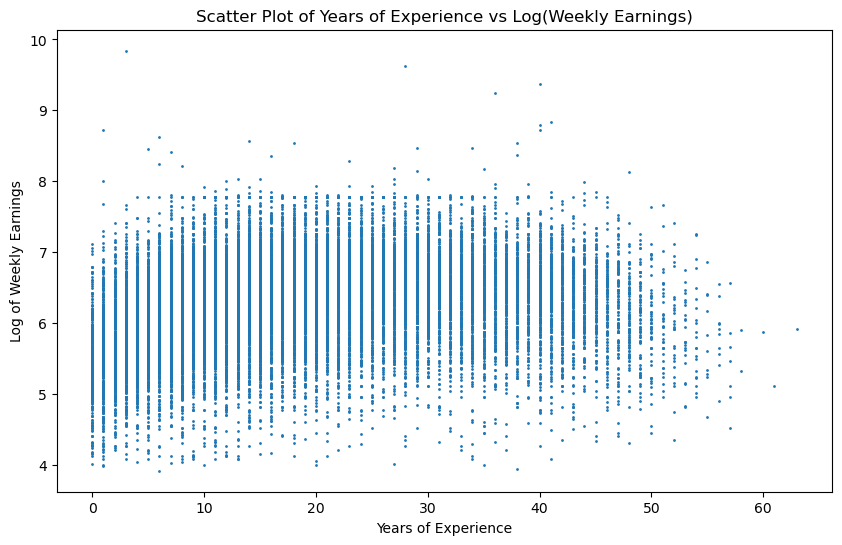

In [2]:
import numpy as np
y = np.log(dt['WeeklyEarnings'])
x = dt['Exper']
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Scatter Plot of Years of Experience vs Log(Weekly Earnings)')
plt.show()

The simplest model is linear regression: $Y = \beta_0 + \beta_1 X + \epsilon$. Let us fit this model using statsmodels, and plot the fitted regression line on the observed scatter plot. 

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     1311.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):          4.67e-280
Time:                        15:42:08   Log-Likelihood:                -23459.
No. Observations:               25437   AIC:                         4.692e+04
Df Residuals:                   25435   BIC:                         4.694e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.0704      0.007    875.641      0.0

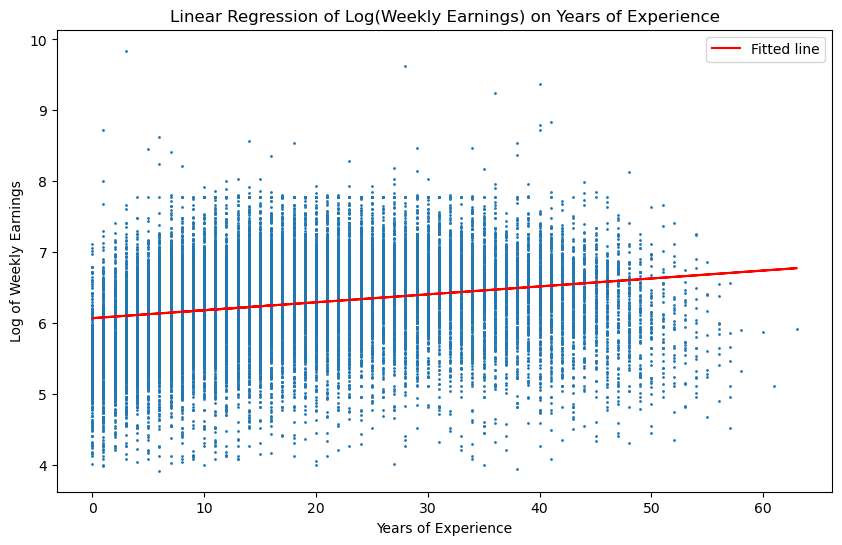

In [3]:
#The simplest model to fit is linear regression: y = b0 + b1 x
import statsmodels.api as sm

X = sm.add_constant(x) #adding intercept
model_1 = sm.OLS(y, X).fit()

print(model_1.summary())

#Plotting the fitted line on the scatter plot
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x, model_1.predict(X), color = 'red', label = 'Fitted line')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Linear Regression of Log(Weekly Earnings) on Years of Experience')
plt.legend()
plt.show()

The fitted regression equation is: $Y  = 6.0704 + 0.0112 X$. The interpretation of the coefficient 0.0112 is as follows. It represents the change in $Y$ for unit increase in $X$. As $Y = \log E$ where $E$ denotes earning. We have
\begin{align*}
   \log E_{\text{new}} - \log E_{\text{old}} = 0.01120
\end{align*}
where $E_{\text{new}}$ denotes weekly earnings for $X = x + 1$ and $E_{\text{old}}$ denotes weekly earnings for $X = x$ (the exact value of $x$ is immaterial for this argument). Because $E_{\text{new}}$ and $E_{\text{old}}$ are expected to be close to each other, we can use $\log x \approx x-1$ for $x \approx 1$ to write
\begin{align*}
   0.0112 = \log E_{\text{new}} - \log E_{\text{old}} = \log \frac{E_{\text{new}}}{E_{\text{old}}} \approx \frac{E_{\text{new}}}{E_{\text{old}}} - 1 = \frac{E_{\text{new}} - E_{\text{old}}}{E_{\text{old}}} 
\end{align*}
Therefore
\begin{align*}
   \frac{E_{\text{new}} - E_{\text{old}}}{E_{\text{old}}} \times 100 \approx 1.12
\end{align*}
which says that weekly earnings increase by 1.12 \% for an additional year of experience. From a look at the scatter plot, it is clear that earnings seems to be decrease when experience is large. This suggests that fitting a single line to this dataset is not the best idea. The common fix is then to include a quadratic term $\text{Exper}^2$ in the model. This leads to the following model: 
\begin{align*}
   Y = \beta_0 + \beta_1 X + \beta_2 X^2
\end{align*}
Even though the right hand side is a quadratic function of $X$, this is also considered a linear model and can be fit by least squares (using the OLS function in statsmodels) as follows:

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.132
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     1939.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:44:26   Log-Likelihood:                -22294.
No. Observations:               25437   AIC:                         4.459e+04
Df Residuals:                   25434   BIC:                         4.462e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.6996      0.010    569.429   

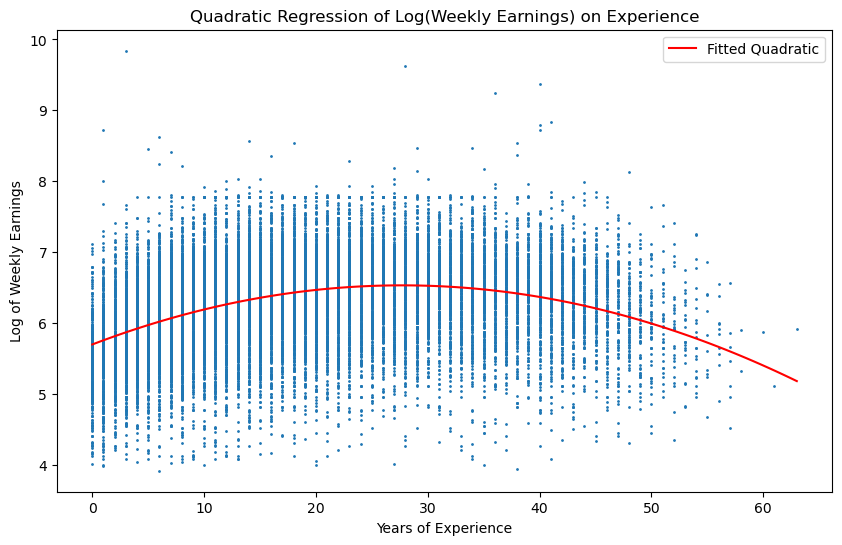

In [4]:
X = sm.add_constant(x)
X['Exper_Square'] = np.square(x)
model_2 = sm.OLS(y, X).fit()

print(model_2.summary())

#Plotting the fitted quadratic on the scatter plot

b0, b1, b2 = model_2.params
x_range = np.linspace(x.min(), x.max(), 100)
fitted_model_2 = b0 + b1*x_range + b2*np.square(x_range)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x_range,fitted_model_2, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Quadratic Regression of Log(Weekly Earnings) on Experience')
plt.legend()
plt.show()

Visually the quadratic model gives a better fit than before. Also the AIC for the second quadratic model is much smaller compared to the simpler linear model. However interpretation of the coefficients is now trickier because of the presence of both $X$ and $X^2$ in the model. The increase in $Y$ when the experience changes from $x$ to $x+1$ is now given by:
\begin{align*}
  \left(\beta_0 + \beta_1 (x+1) + \beta_2 (x+1)^2 \right) - \left(\beta_0 + \beta_1 x + \beta_2 x^2 \right) = \beta_1 + \beta_2 (2x + 1)
\end{align*}
Thus the percentage increase for an additional year of experience when the experience is $x$ is given by $100 \left( \beta_1 + \beta_2 (2x + 1)\right)$.

In [ ]:
#Coefficient interpretation for the quadratic model:
#Interpretation of the coefficients is now trickier because of the square term
#Now the percentage increase for an additional year of experience is given by: 
#100*(b1 + 2*Exper*b2 + b2). For example if Exper = 0, then this is 100*(b1 + b2) which is approximately 6%
#If Exper = 25, then this is 100*(b1 + 50*b2+b2) = 
exper_value = 50
perc_increase = 100*(b1 + 2*exper_value*b2 + b2)
print(perc_increase)

From the equation of the fitted quadratic function, it is easy to calculate the value of the point where the quadratic goes from increasing to decreasing. This is the peak of the quadratic and represents the point beyond which weekly wages go down with further increases in experience. 

In [5]:
#The point where the quadratic goes from increasing to decreasing is given by: 
peak_quadratic = -b1/(2*b2)
print(peak_quadratic)

27.72060595169243


### Broken Stick Regression

The quadratic term is not the only way of fitting a nonlinear curve to this dataset. Another option is to use broken stick regression. Here one adds an additional term of the form $(x - s)_+ := \max(x-s, 0)$ to the simple equation $Y = \beta_0 + \beta_1 X$ to get the new equation:
\begin{align*}
    Y = \beta_0 + \beta_1 X + \beta_2 (X - s)_+
\end{align*}
Here $s$ is known as a 'break-point' or 'knot'. The coefficients of this equation are easier to interpret compared to the quadratic equation $Y = \beta_0 + \beta_1 X + \beta_2 X^2$. Specifically, $\beta_1$ is the slope for $x \leq s$ and $\beta_1 + \beta_2$ is the slope for $x \geq s$. In this example, $100*\beta_1$ denotes the percent increase in weekly earnings for every additional year of experience when experience is less than $s$, and $100*(\beta_1 + \beta_2)$ denotes the percent increase in weekly earnings for every additional year of experience when experience is more than $s$. 

The following code illustrates how this model can be fit using the OLS function in statsmodels. We are using $s = 27$ for the code below. The choice of $s = 27$ is motivated by the fact that the quadratic fit has its peak close to 27.

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     1653.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:45:01   Log-Likelihood:                -22545.
No. Observations:               25437   AIC:                         4.510e+04
Df Residuals:                   25434   BIC:                         4.512e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   5.8595    

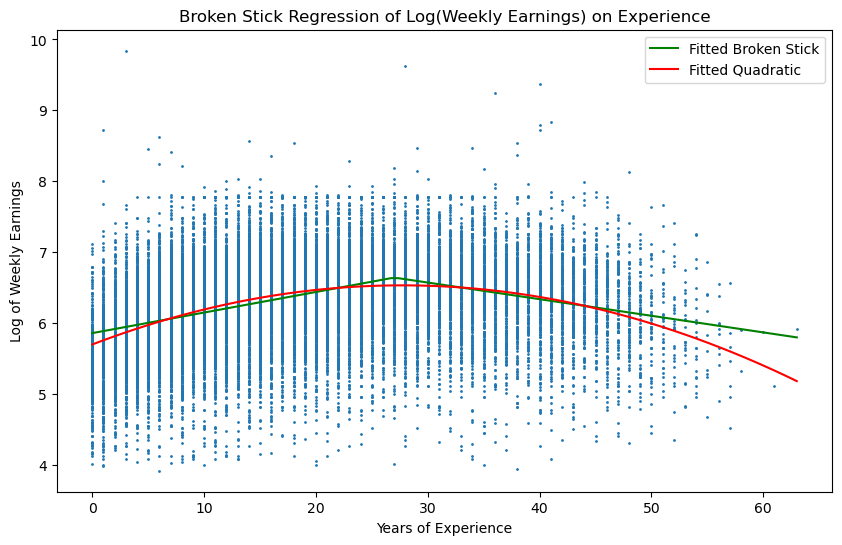

In [6]:
#Suppose we go back to the linear model, and instead of
#adding the quadratic term, we add the term (x - 27)_+ leading to the model:
#y = b0 + b1 x + b2 (x - 27)_+
#This model keeps the slope b1 for x smaller than 27, but after 27 it modifies the slope to b1 + b2
#We would expect b2 to be negative. 
#This model can also be fit by usual linear regression

X = sm.add_constant(x) #adding intercept
X['pos_part_x_minus_27'] = np.maximum(x - 27, 0)
model_3 = sm.OLS(y, X).fit()

print(model_3.summary())

#Plotting the fitted equation on the scatter plot:

b0, b1, b2 = model_3.params
x_range = np.linspace(x.min(), x.max(), 100)
fitted_model_3 = b0 + b1*x_range + b2*np.maximum(x_range-27,0)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x_range,fitted_model_3, color = 'green', label = 'Fitted Broken Stick')
plt.plot(x_range, fitted_model_2, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Broken Stick Regression of Log(Weekly Earnings) on Experience')
plt.legend()
plt.show()

In [ ]:
#This model has an AIC that is much smaller than the first model (simple linear regression)
#But its AIC is still larger than that of the quadratic model (indicating the quadratic
#model is a better fit). However, the coefficients in this model are easier to interpret
#corresponding to the quadratic model. 
#For x <= 27, wages increase by 100*b1 = 2.9% for every additional year in experience
#For x >= 27, wages increase by 100*(b1 + b2) = -2.34% for every additional year in experience
print(100*(b1 + b2))

Because the fitted function looks like a broken stick, this is known as Broken Stick Regression. The choice of knot $s$ (which we took as $s = 27$) is crucial to the quality of the fit to data. A natural data-driven strategy to select $s$ is to go over all possible values for $s$, and then choose the knot which gives the smallest AIC (or, equivalently, the highest log-likelihood). This can be done using the code shown below. 

In [7]:
#Below we search over all possible knots and then 
#choose the knot with the highest log-likelihood:
best_knot = None
highest_log_likelihood = -np.inf

for knot in range(1, 63):
    X = sm.add_constant(x)
    X['knot_variable'] = np.maximum(x - knot, 0)
    model_knot = sm.OLS(y, X).fit()
    if model_knot.llf > highest_log_likelihood:
        highest_log_likelihood = model_knot.llf
        best_knot = knot

print(f"The knot with highest log-likelihood is: {best_knot}")
print(f"Highest Log-Likelihood: {highest_log_likelihood}")


The knot with highest log-likelihood is: 17
Highest Log-Likelihood: -22398.051362075297


The best knot (i.e., the knot with the highest log-likelihood or smallest AIC) turned out to be 17 (which is much smaller than our initial choice $s = 27$). Below we fit the broken stick regression model with knot chosen to be 17. 

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     1819.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:45:26   Log-Likelihood:                -22398.
No. Observations:               25437   AIC:                         4.480e+04
Df Residuals:                   25434   BIC:                         4.483e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.7143      0.010    567.213

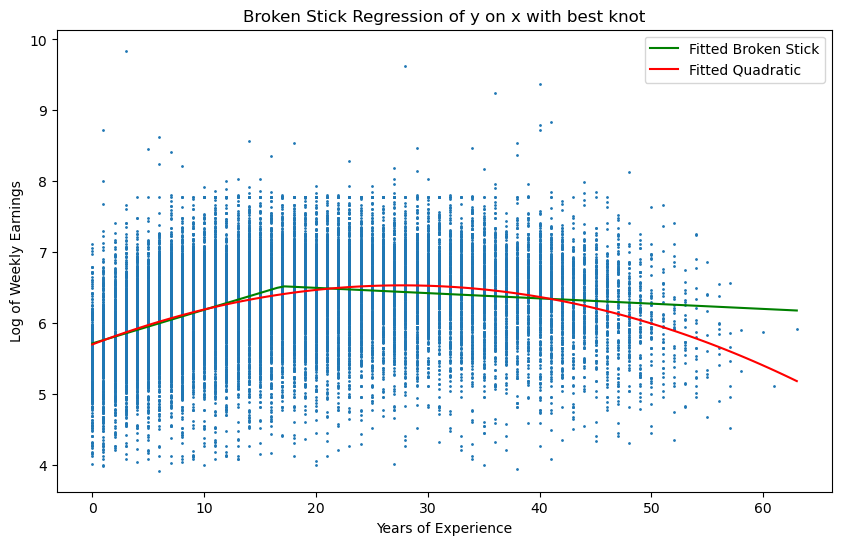

In [8]:
#We can now fit the model with the best_knot
X = sm.add_constant(x) #adding intercept
X['knot_variable'] = np.maximum(x - best_knot, 0)
model_4 = sm.OLS(y, X).fit()

print(model_4.summary())

#Plotting the fitted equation on the scatter plot

b0, b1, b2 = model_4.params
x_range = np.linspace(x.min(), x.max(), 100)
fitted_model_4 = b0 + b1*x_range + b2*np.maximum(x_range-best_knot,0)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x_range,fitted_model_4, color = 'green', label = 'Fitted Broken Stick')
plt.plot(x_range,fitted_model_2, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Broken Stick Regression of y on x with best knot')
plt.legend()
plt.show()

### Regression Models with more knots

The model from the previous section with the best knot still had an inferior AIC compared to fitting the quadratic function. We can further improve the broken stick regression model by adding more knot variables. For example, adding one more knot variable leads to the equation:
\begin{align*}
   Y = \beta_0 + \beta_1 X + \beta_2 (X - s_1)_+ + \beta_3 (X - s_2)_+
\end{align*}
The code below demonstrates fitting this model with $s_1 = 17$ and $s_2 = 35$ (the choice $s_2 = 35$ is arbitrary).

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.130
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     1267.
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:45:43   Log-Likelihood:                -22327.
No. Observations:               25437   AIC:                         4.466e+04
Df Residuals:                   25433   BIC:                         4.470e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             5.7340      0.010    563.180

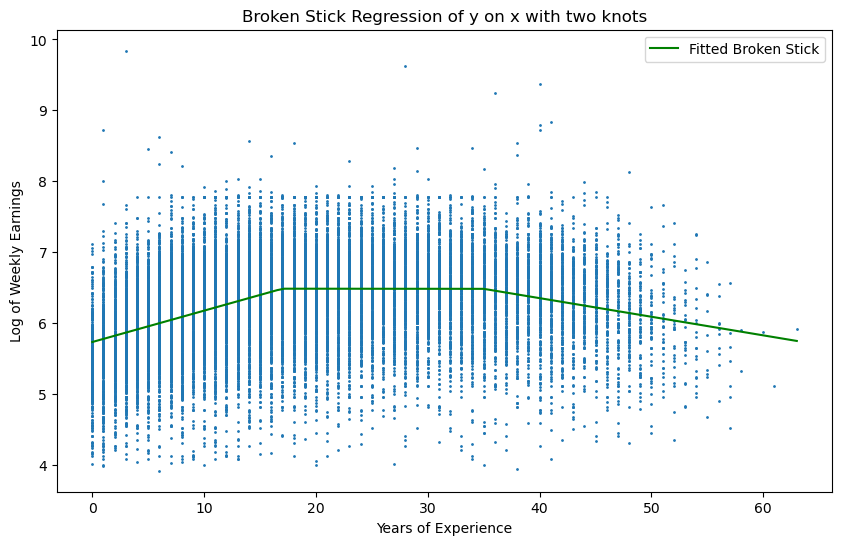

In [9]:
#We can further improve the broken stick regression model by adding more knot variables. 
#Suppose we add another knot variable at 35:
new_knot = 35
X = sm.add_constant(x) #adding intercept
X['knot_variable'] = np.maximum(x - best_knot, 0)
X['another_knot'] = np.maximum(x - new_knot, 0)

model_5 = sm.OLS(y, X).fit()

print(model_5.summary())

#Plotting the fitted quadratic on the scatter plot

b0, b1, b2, b3 = model_5.params
x_range = np.linspace(x.min(), x.max(), 100)
fitted_model_5 = b0 + b1*x_range + b2*np.maximum(x_range-best_knot,0) + b3 * np.maximum(x_range - new_knot, 0)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x_range,fitted_model_5, color = 'green', label = 'Fitted Broken Stick')
#plt.plot(x_range,fitted_model_2, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Broken Stick Regression of y on x with two knots')
plt.legend()
plt.show()

With the two additional terms $(x - s_1)_+$ and $(x - s_2)_+$, the percentage increase in wages for an additional year of experience depends on whether the current experience level is less than $s_1$, between $s_1$ and $s_2$, or more than $s_2$:

In [ ]:
#Interpretation of the coefficients:
#for x < 17, the slope is b1. So Wages increase by 100*b1 = 4.42% for every one year increase in experience
# for x between 17 and 35, slope is b1 + b2. So wages increase by 100*(b1 + b2) for every one year increase in experience:
print(100*(b1 + b2))
#for x larger than 35, slope is b1 + b2 + b3. So wages increase by 100*(b1 + b2 + b3):
print(100*(b1 + b2 + b3))

One can more knot variables to the equation to obtain models of the form: 
\begin{align*}
   Y = \beta_0 + \beta_1 X + \beta_2 (X - s_1)_+ + \beta_3 (X - s_2)_+ + \dots + \beta_{k+1} (X - s_k)_+
\end{align*}
While this model is conceptually interesting, one has to deal with the following annoying issues: 

1. It is difficult to select a suitable value of $k$. 
2. For a given choice of $k$, it is quite difficult to select the knots $s_1, \dots, s_k$ in a principled manner. If $k$ is very small, one can go over all possible values for these knots and then select the best set of knots using AIC or log-likelihood. But this process is computationally intractable if $k$ is even moderately large.  

One way to circumvent these problems is to introduce a change of slope
term $(x - s)_+$ at every possible value of $s$. 

### All knots: high-dimensional linear model

In this dataset, the
variable $X$ takes the values $0, 1, \dots, 63$. Considering all these possible knots (with the exception of the last value 63 because $(X - 63)_+$ is always zero) leads us to the model equation:
$$
  Y = \beta_0 + \beta_1 X + \beta_2 (X - 1)_+ + \beta_3 (X - 2)_+
  + \dots + \beta_{63}(X - 62)_+ \tag{1}
$$
This is a linear regression
model with $64$ coefficients. The interpretation of the regression
coefficients are as follows. $\beta_0$ is the simply the value of $Y = 
\log(\text{Earnings})$ when $X = 0$ (i.e., for someone just joining the
workforce). To obtain the interpretation for $\beta_1$, first plug in
$X = 1$ in the model equation and then $X = 0$ and subtract the second
equation from the first. This gives
\begin{equation*}
  \beta_1 = Y_1 - Y_0 = \log(E_1) - \log(E_0) =
  \log\left(\frac{E_1}{E_0} \right) \approx \frac{E_1 - E_0}{E_0}. 
\end{equation*}
Here $E_0$ and $E_1$ are Earnings for $X =  0$ and $X = 1$
respectively, and in the last equality, we again used $\log(u) \approx u -
1$ for $u \approx 1$. Thus $100\beta_1$ represents the increment  (in
percent) in salary from year 0 to year 1. For example, $\beta_1 =
0.05$ means that the salary increases by $5\%$ from year 0 to year 1. What is the
interpretation for $\beta_2$? It is easy to see that:
\begin{equation*}
  \log E_2 = \beta_0 + 2 \beta_1 + \beta_2 ~~~ \log E_1 = \beta_0 +
  \beta_1 ~~~ \log E_0 = \beta_0. 
\end{equation*}
Thus
\begin{equation*}
  \beta_2 = \log E_2 - 2 \log E_1 + \log E_0 = \log \frac{E_2}{E_1} -
  \log \frac{E_1}{E_0} \approx \frac{E_2 - E_1}{E_1} - \frac{E_1 -
    E_0}{E_0}. 
\end{equation*}
Thus $100 \beta_2$ represents the change in the percent increment
between years 1 and 2 compared to the percent increment between years
0 and 1. For example, $\beta_2 = -0.0003$ means that the percent
increment decreases by $0.03$ after year 2. If $\beta_1 = 0.05$, we
would have a $5\%$ increment after year 1 and a $5 - 0.03 = 4.97\%$
increment after year 2. More generally, the interpretation for
$\beta_j, j \geq 2$ is as follows: $100\beta_j$ is the change in the
percent increment between years $j-1$ and $j$ compared to the percent
increment between years $j-2$ and $j-1$. For a concrete example,
suppose
\begin{equation*}
  \beta_0 = 5.74 ~~~ \beta_1 = 0.05 ~~~ \beta_2 = -0.0003 ~~~ \beta_3 =
  -0.0008 ~~~ \beta_4 = -0.001 ~~~ \dots
\end{equation*}
then

1. weekly earnings for someone just joining the workforce is
  $\exp(5.74) = \$311.06$, 
2. increment after year 1 is $5 \%$, 
3. increment after year 2 is $(5 - 0.03) = 4.97 \%$,
4. increment after year 3 is $(4.97 - 0.08) = 4.89\%$,
5. increment after year 4 is $(4.89 - 0.1) = 4.79 \%$, and so on. 

If all $\beta_j, j \geq 2$ are negative, then, after a
while, the increments may become negative which means that the salary
actually starts decreasing after a certain number of years of
experience.

The all knots regression model (in equation (1)) can also be fit by the OLS function in statsmodels. However it is usually not a good idea to fit a linear regression model with many covariates using plain old OLS. The reason is that there will be overfitting leading to poor interpretability and poor predictive power. We shall demonstrate this below. 

In [10]:
#Here is how we can use OLS to fit the regression model with all possible knots 1, 2,.., 62.
X = sm.add_constant(x) #adding intercept
for knot in range(1, 63):
    X[f'knot_{knot}'] = np.maximum(x - knot, 0)

model_all_knots = sm.OLS(y, X).fit()
print(model_all_knots.summary())

                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     67.42
Date:                Wed, 08 Jul 2026   Prob (F-statistic):               0.00
Time:                        15:52:34   Log-Likelihood:                -22188.
No. Observations:               25437   AIC:                         4.450e+04
Df Residuals:                   25375   BIC:                         4.501e+04
Df Model:                          61                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4711      0.030    185.217      0.0

The main problem with the above OLS output is that the estimated regression coefficients are not interpretable. To see this, note that the fitted coefficients are:
\begin{equation*}
  \beta_0 = 5.4711 ~~~ \beta_1 = 0.1347 ~~~ \beta_2 = 0.0323 ~~~ \beta_3 =
  -0.0847 ~~~ \beta_4 = 0.0185 ~~~ \dots
\end{equation*}
so that the interpretations become

1. weekly earnings for someone just joining the workforce is
  $\exp(5.4711) = \$237.72$, 
2. increment after year 1 is $13.47 \%$, 
3. increment after year 2 is $(13.47 + 3.23) = 16.7 \%$,
4. increment after year 3 is $(16.7 - 8.47) = 8.23\%$,
5. increment after year 4 is $(8.23 + 1.85) = 10.08 \%$, and so on.

Clearly the increments are quite large, and they also oscillate somewhat wildly from year to year. So the fitted model is somewhat nonsensical.

No one would want to use this fitted model because of poor interpretability. One can also plot the fitted function on the scatter plot of the data as shown below. The fitted function is quite wiggly. 


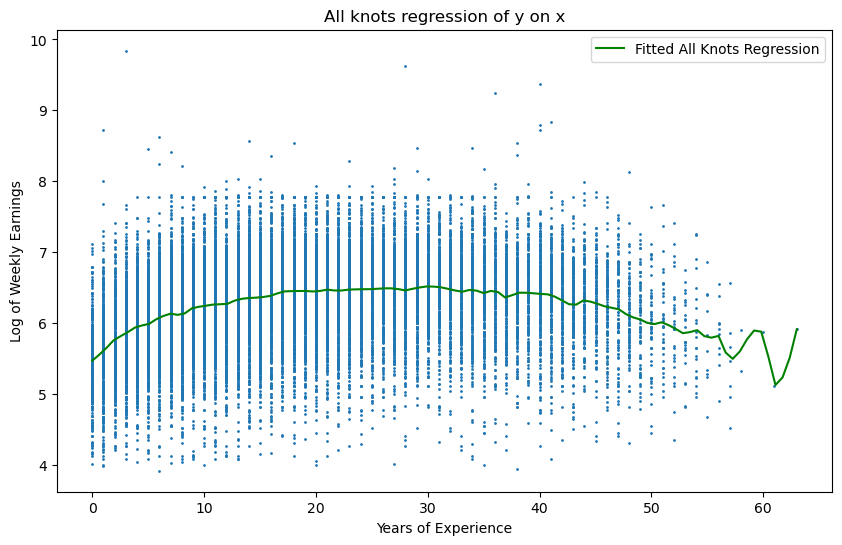

In [11]:
#Plotting the fitted values of this model: 
# Generate x_range for plotting
x_range = np.linspace(x.min(), x.max(), 100)

# Prepare a DataFrame for x_range
X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, 63):
    X_range[f'knot_{knot}'] = np.maximum(X_range['x'] - knot, 0)

fitted_model_all_knots = model_all_knots.predict(X_range)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression')
#plt.plot(x_range,fitted_model_2, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

The reason why this 'all-knots' regression model is giving us a poor fit is not because the model itself is inadequate but it is rather because of the use of OLS to estimate its coefficients. The sample size here is quite large ($n = 25437$). The problem is much worse if the sample size were smaller. To illustrate this, consider fitting this model to a smaller dataset obtained by randomly sampling $n = 500$ observations from the full dataset. This is demonstrated below. 

In [12]:
#Repeating the analysis on a smaller dataset: 
n = 500
random_seed = 42
dt_small = dt.sample(n = 500, random_state = random_seed)
print(dt_small.shape)
print(dt_small.head())

(500, 5)
          Region   MetropolitanStatus  Exper  Educ  WeeklyEarnings
8735        West     MetropolitanArea     19    14          735.99
13369  Northeast  NotMetropolitanArea     15    16          807.22
5512     Midwest  NotMetropolitanArea     18    16          341.88
24277      South  NotMetropolitanArea     32    12          240.38
24959      South     MetropolitanArea     14    16         1210.83


                            OLS Regression Results                            
Dep. Variable:         WeeklyEarnings   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     55.83
Date:                Wed, 08 Jul 2026   Prob (F-statistic):           1.34e-22
Time:                        15:53:11   Log-Likelihood:                -405.85
No. Observations:                 500   AIC:                             817.7
Df Residuals:                     497   BIC:                             830.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            5.6176      0.069     81.159   

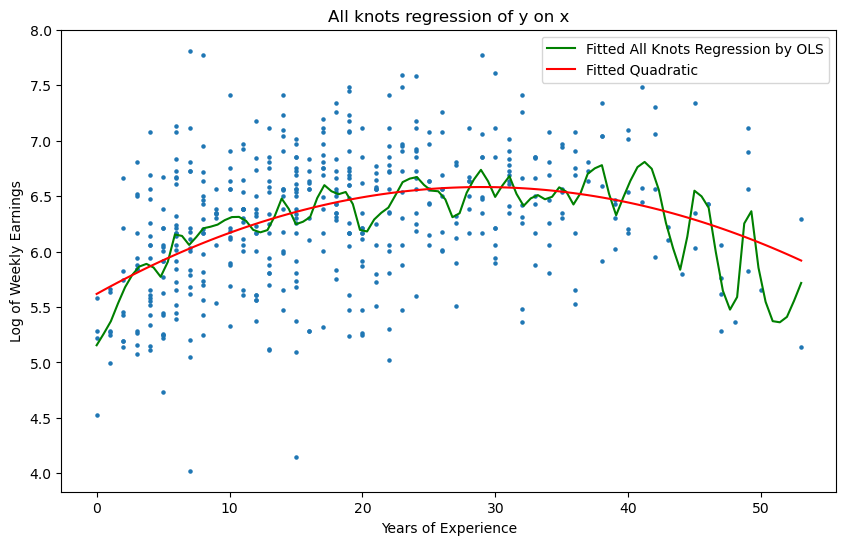

In [13]:
#Let us now repeat the exercise fitting the quadratic model as well as the all-knots regression model on this smaller dataset: 
y = np.log(dt_small['WeeklyEarnings'])
x = dt_small['Exper']

#Quadratic model: 
X = sm.add_constant(x)
X['Exper_Square'] = np.square(x)
model_quad = sm.OLS(y, X).fit()

print(model_quad.summary())

#Plotting the fitted quadratic on the scatter plot
b0, b1, b2 = model_quad.params
x_range = np.linspace(x.min(), x.max(), 100)
fitted_model_quad = b0 + b1*x_range + b2*np.square(x_range)

X_all_knots = sm.add_constant(x) #adding intercept
for knot in range(1, 63):
    X_all_knots[f'knot_{knot}'] = np.maximum(x - knot, 0)
model_all_knots = sm.OLS(y, X_all_knots).fit()

print(model_all_knots.summary())

# Prepare a DataFrame for x_range
X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, 63):
    X_range[f'knot_{knot}'] = np.maximum(X_range['x'] - knot, 0)

fitted_model_all_knots = model_all_knots.predict(X_range)

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

Now the coefficients oscillate even more wildly to make interpretation fully nonsensical. Indeed now
\begin{equation*}
  \beta_0 = 5.1547 ~~~ \beta_1 = 0.1953 ~~~ \beta_2 = 0.1042 ~~~ \beta_3 =
  -0.0938 ~~~ \beta_4 = -0.1610 ~~~ \dots
\end{equation*}
so that the interpretations become

1. weekly earnings for someone just joining the workforce is
  $\exp(5.4711) = \$173.24$, 
2. increment after year 1 is $19.53 \%$, 
3. increment after year 2 is $(19.53 + 10.42) = 29.95 \%$,
4. increment after year 3 is $(29.95 - 9.38) = 20.57\%$,
5. increment after year 4 is $(20.57 - 16.10) = 4.47 \%$, and so on.

Clearly these numbers are meaningless. Moreover the AIC and BIC now are both larger than that of the quadratic model. In situations such as this where the OLS is giving meaningless results, one uses regularization.

## Regularization

Given the interpretation of the betas, it is natural in this problem to think that the betas should mostly be small.  We have seen previously that the OLS estimates can be seen as Bayesian estimates under the flat prior i.e., under the prior 
\begin{align*}
  \beta_0, \beta_1, \dots, \beta_m \overset{\text{i.i.d}}{\sim} \text{Unif}(-C, C)
\end{align*}
for a large $C$. This allows the betas to be quite large. The idea of regularization is to further constrain the values of beta to take on small values. This can be done by setting an appropriate prior which gives higher probability to smaller values. We shall now see how to do this. 



The $\text{Unif}(-C, C)$ prior with very large $C$ is flat in the region of plausibility of the $\beta$'s. There are also other ways of making flat priors. The normal density $N(0, C)$ with mean $0$ and variance $C$ is also an example of a flat prior when $C$ is very large. This is because the normal density is given by $\frac{1}{\sqrt{2\pi C}} \exp \left(-\beta_j^2/(2C) \right)$. The exponential term is essentially 1 when $C$ is very large so that the prior density does not depend on the value $\beta_j$ and is therefore flat. Thus the OLS estimates in linear regression can also be seen as Bayesian estimates under the prior: 
\begin{align*}
   \beta_0, \beta_1, \dots, \beta_m \overset{\text{i.i.d}}{\sim} N(0, C) \tag{Flat}
\end{align*}
where $C$ is very large. When the OLS estimates are giving strange results, it means that the above prior is not a useful one. In such cases, one should look for alternative priors. In the specific example of the all-knots regression model, here is a reasonable alternative prior: 
\begin{align*}
   \beta_0 \sim N(0, C) ~~ \beta_1 \sim N(0, C) ~~ \text{ and } ~~ \beta_2, \dots, \beta_{63} \overset{\text{i.i.d}}{\sim} N(0, \tau^2) \tag{Regularizing Prior}
\end{align*}
for $\tau^2$ that is not necessarity set to be some large value. This prior is more flexible
compared to previous flat prior because we can get back the flat prior by taking
$\tau = \sqrt{C}$. But here we have the flexibility of taking $\tau$
small (if it leads to a better fit to the data) which will lead to
smooth function fits. The assumption $\beta_0, \beta_1
\overset{\text{i.i.d}}{\sim} N(0, C)$ just says
that we do not enforce anything on $\beta_0$ and $\beta_1$ a
priori. We can write the regularizing prior as
\begin{equation*}
  \beta \sim N_{64}(m_0, Q_0)
\end{equation*}
where $\beta$ is the $64 \times 1$ vector with components $\beta_0,
\beta_1, \dots, \beta_{63}$, $m_0$ is the $64 \times 1$ vector of
zeros, and $Q_0$ is the $64 \times 64$ diagonal matrix with diagonal
entries $C,C, \tau^2, \dots, \tau^2$. To calculate the posterior
distribution of $\beta$, we shall use the following fact (below $m_0,
Q_0, X, \sigma$ should be treated as non-random)
\begin{equation*}
  \beta \sim N_p(m_0, Q_0) \text{ and } Y \mid \beta \sim N_n(X \beta,
  \sigma^2 I_n) \implies \beta \mid Y \sim N_p(m_1, Q_1)
\end{equation*}
where
\begin{equation*}
  m_1 = \left(Q_0^{-1} + \frac{1}{\sigma^2}X^T X \right)^{-1}
  \left(Q_0^{-1} m_0 + \frac{1}{\sigma^2}X^T Y \right) ~~~ \text{ and
  } ~~~ Q_1 = \left(Q_0^{-1} + \frac{1}{\sigma^2}X^T X \right)^{-1}. 
\end{equation*}
Here $N_p$ and $N_n$ denote the multivariate normal distributions on $p$ dimensions and $n$ dimensions respectively. Using this result, the posterior of $\beta$ with the regularizing prior 
is
\begin{equation*}
  \beta \mid \text{data}, \sigma \sim N_{64} \left( \left(Q_0^{-1} +
      \frac{1}{\sigma^2} X^T X \right)^{-1} \frac{1}{\sigma^2} X^T Y, \left(Q_0^{-1} +
      \frac{1}{\sigma^2} X^T X \right)^{-1} 
  \right). 
\end{equation*}
This posterior can be used for inference on $\beta$. Note that it
depends on $\tau$ and $\sigma$. One can take a small value for $\tau$
if smooth function fit is desired. The posterior mean is
\begin{equation*}
  \tilde{\beta}^{\tau} = \left(Q_0^{-1} +
      \frac{1}{\sigma^2} X^T X \right)^{-1} \frac{1}{\sigma^2} X^T Y
  \end{equation*}
  which can be used to get the function fit:
  $$
    \tilde{f}^{\tau}(x) := \tilde{\beta}^{\tau}_0 + \tilde{\beta}_1^{\tau} x + \tilde{\beta}^{\tau}_2 (x - 1)_+ + \tilde{\beta}^{\tau}_3 (x - 2)_+ + \dots + \tilde{\beta}^{\tau}_{63}(x - 62)_+. 
$$
When $\tau$ is small, it can be checked that $\tilde{f}^{\tau}(x)$ will
be a very smooth function of $x$. If $\tau$ is really really small,
then $\tilde{f}^{\tau}(x)$ will be essentially a line. If $\tau$ is large, then we revert back to the OLS estimate.

In the code below, set $\tau$ to multiple values ranging from small to large and see how the estimate varies. 

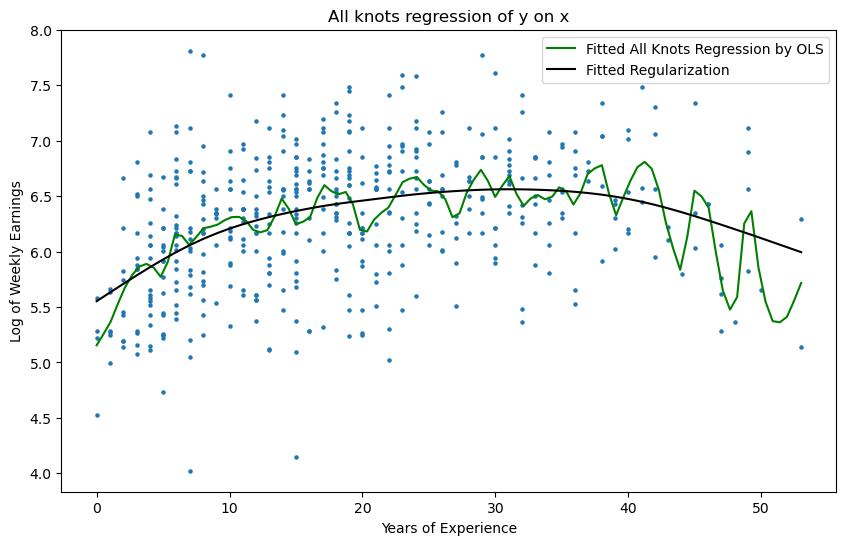

In [14]:
#In order to work with the regularizing prior, we need to set the values of C, tau, sigma:
C = 10 ** 6 #some large value
#tau = 0.001 #set tau = 0.001, tau = 0.01, tau = 0.1, tau = 1, tau = 2
tau = .01
sig = 0.6

kmax = 62

Q0 = np.diag([C, C] + [tau ** 2] * kmax) #this is the prior covariance matrix of b0, b1, b2, ...b(kmax + 1)
#Q0 is a diagonal matrix with C in the first two entries and the rest of entries equal tau^2

TempMat = np.linalg.inv((sig**2) * np.linalg.inv(Q0) + X_all_knots.T @ X_all_knots) #this is the matrix which
#multiplies X^T Y to give the posterior mean
post_mean = TempMat @ (X_all_knots.T @ y.to_numpy().reshape(-1, 1))

#calculating the fitted values for a grid of x-values:
x_range = np.linspace(x.min(), x.max(), 100)

X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, (1 + kmax)):
    X_range[f'knot_{knot}'] = np.maximum(x_range - knot, 0)

fitted_model_regularized = X_range.values @ post_mean


plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
#plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.plot(x_range,fitted_model_regularized, color = 'black', label = 'Fitted Regularization')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

In the above code, with $\tau$ large (say $\tau = 2$), there is very little difference between the regularized fit and the OLS fit. With $\tau$ smaller $\tau = 0.01$, the regularized fit is very similar to the quadratic function fit. With even smaller $\tau$: $\tau = 0.001$, the regularized fit is the same as simple linear regression. Thus by varying $\tau$ from small to large, one gets a nice range of fits from simple linear regression to quadratic to the full all-knots OLS. 

In practice, one would need to choose the value of $\tau$. One way would be to try various values of $\tau$ and pick the value which visually seems to give a good fit. The (Empirical) Bayesian formulation gives a more principled way of choosing $\tau$ using marginal likelihood. 

## Choosing $\tau$ and $\sigma$ via Marginal Likelihood

One way of selecting $\tau$ and $\sigma$ is by maximizing the likelihood of the data given only $\tau$ and $\sigma$. In usual linear regression, the likelihood is a function of $\beta_0, \beta_1, \dots, \beta_m$ and $\sigma$ and is given by the density of $N_n(X\beta, \sigma^2 I_n)$. Now since we have a prior on $\beta_0, \dots, \beta_m$, we can integrate out $\beta_0, \dots, \beta_m$ (with respect to the prior) to obtain a marginal likelihood which is a function of $\tau$ and $\sigma$. Fortunately, this integral can be obtained in closed form because of the following result: 
\begin{equation*}
  \beta \sim N_p(m_0, Q_0) \text{ and } Y \mid \beta \sim N_n(X \beta,
  \sigma^2 I_n) \implies Y \sim N \left(X m_0, X Q_0 X^T + \sigma^2
    I_n\right). 
\end{equation*}
Therefore (note that for us $m_0$ is the zero vector) the marginal likelihood as a function of $\tau$ and $\sigma$ is given by: 
$$
  f_{\text{data} \mid \tau, \sigma}(\text{data}) =
  \left(\frac{1}{\sqrt{2\pi}}\right)^n \left(\det \Sigma
  \right)^{-1/2} \exp \left(-\frac{1}{2} Y^T \Sigma^{-1} Y  \right)
  ~~~ \text{with  $\Sigma := X Q_0 X^T + \sigma^2 I_n$}. 
$$
Recall that $Q_0$ is the diagonal matrix with diagonal entries $C, C,
\tau^2, \dots, \tau^2$. Throughout $C$ is a large constant (e.g., $C = 10^6$). We can maximize the logarithm of the above marginal likelihood: 
\begin{align*}
   \log f_{\text{data} \mid \tau, \sigma}(\text{data}) = - n \log \sqrt{2 \pi} - \frac{1}{2} \log \det \Sigma - \frac{1}{2} Y^T \Sigma^{-1} Y
\end{align*}
over $\tau$ and $\sigma$ to get their estimates (note that $\Sigma$ above equals $X Q_0 X^T + \sigma^2 I_n$ and hence depends on both $\tau$ and $\sigma$). One way of doing this maximization is to take a grid of $\tau$ and $\sigma$ values, calculating the marginal likelihood at each value of the grid and then taking the maximizer. This is illustrated in the code below. 

In [15]:
# Marginal Likelihood Maximization for tau and sigma:
# We first set grids for tau and sigma:
taugrid = np.logspace(np.log10(0.001), np.log10(0.1), 50)
siggrid = np.logspace(np.log10(0.1), np.log10(1), 50)
g = pd.DataFrame([(tau, sig) for tau in taugrid for sig in siggrid], columns=['tau', 'sig'])

C = 10 ** 6
for i in range(len(g)):
    tau_val = g.loc[i, 'tau']
    sig_val = g.loc[i, 'sig']
    Q0 = np.diag([C, C] + [tau_val ** 2] * kmax)
    Sigmat = X_all_knots.values @ Q0 @ X_all_knots.values.T + np.diag([sig_val ** 2] * n)
    cov_inv = np.linalg.inv(Sigmat)
    sign, log_cov_det = np.linalg.slogdet(Sigmat)
    norm_factor = n*np.log(2*np.pi) + log_cov_det
    g.loc[i, 'loglik'] = -0.5 * (norm_factor + y.T @ cov_inv @ y) #this is the log marginal density

ind_max = g['loglik'].idxmax()
print(g.loc[ind_max])

tau         0.013895
sig         0.542868
loglik   -432.733140
Name: 1436, dtype: float64


In [16]:
#The best values of tau and sig selected are
tau_best = g.loc[ind_max, 'tau']
sig_best = g.loc[ind_max, 'sig']
print(tau_best, sig_best)

0.013894954943731374 0.5428675439323859


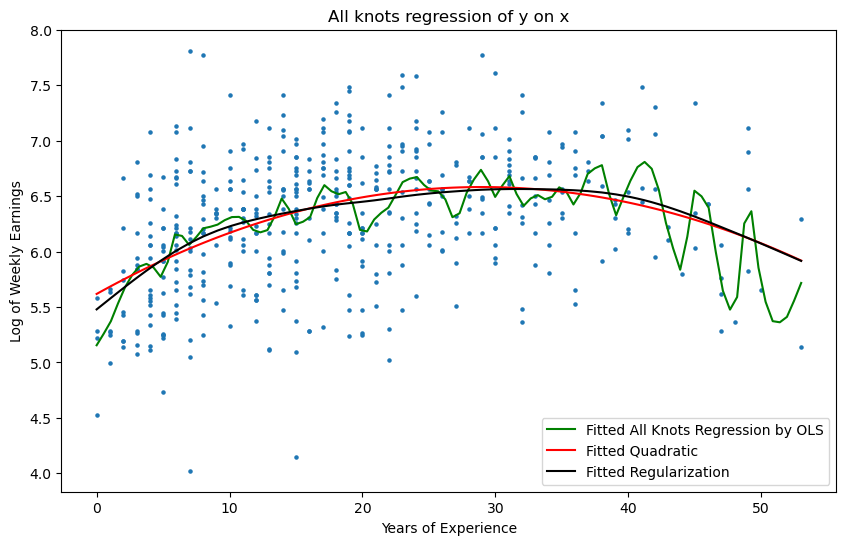

In [17]:
#Now we calculate the posterior mean with the best values for tau and sig:
C = 10 ** 6 #some large value
tau = tau_best
sig = sig_best

kmax = 62

Q0 = np.diag([C, C] + [tau ** 2] * kmax) #this is the prior covariance matrix of b0, b1, b2, ...b(kmax + 1)
#Q0 is a diagonal matrix with C in the first two entries and the rest of entries equal tau^2

TempMat = np.linalg.inv((sig**2) * np.linalg.inv(Q0) + X_all_knots.T @ X_all_knots) #this is the matrix which
#multiplies X^T Y to give the posterior mean
post_mean = TempMat @ (X_all_knots.T @ y.to_numpy().reshape(-1, 1))

#calculating the fitted values for a grid of x-values:
x_range = np.linspace(x.min(), x.max(), 100)

X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, 63):
    X_range[f'knot_{knot}'] = np.maximum(x_range - knot, 0)

fitted_model_regularized = X_range.values @ post_mean


plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.plot(x_range,fitted_model_regularized, color = 'black', label = 'Fitted Regularization')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

Note that the best regularized fit (given in black in the plot above) is similar to but not exactly same as the quadratic fit. For example, for small $x$, the regularized fit is steeper, for $x$ near the middle, the regularized fit is flatter compared to the quadratic fit. 

## Regularization via Full Bayesian Inference

We work with the following prior:
\begin{align*}
   \beta_0, \beta_1 \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C) ~~~ \beta_2, \dots, \beta_{m} \overset{\text{i.i.d}}{\sim} N(0, \gamma^2 \sigma^2)
\end{align*}
We treat $\gamma$ and $\sigma$ also as unknown parameters and assign the prior: 
\begin{align*}
    \log \gamma, \log \sigma \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C). 
\end{align*}


The posterior of $\gamma, \sigma, \beta$ can be described as follows. 


The posterior of $\beta$ conditional on $\sigma$ and $\gamma$ is given by: 
\begin{align*}
   \beta \mid \text{data}, \sigma, \tau \sim N \left(\left(\frac{X^T
                          X}{\sigma^2} + Q^{-1}  \right)^{-1} \frac{X^T y}{\sigma^2},  \left(\frac{X^T X}{\sigma^2} + Q^{-1} \right)^{-1}\right). 
\end{align*}
where $Q$ is the diagonal matrix with diagonal entries $C, C, \gamma^2\sigma^2, \dots, \gamma^2\sigma^2$. We use the approximation: 
\begin{align*}
   Q^{-1} = \text{diag}(1/C, 1/C, 1/\tau^2, \dots, 1/\tau^2) \approx \text{diag}(0, 0, 1/\tau^2, \dots, 1/\tau^2) = \frac{J}{\tau^2}
\end{align*}
where $J$ is the diagonal matrix with diagonals $0, 0, 1, \dots, 1$. 


The posterior mean of $\beta$ given $\sigma, \tau$ is 
\begin{align*}
   \mathbb{E}(\beta \mid \text{data}, \sigma, \gamma) = \left(\frac{X^T X}{\sigma^2} + \frac{J}{\sigma^2 \gamma^2} \right)^{-1} \frac{X^T y} {\sigma^2} = \left(X^T X + \frac{J}{\gamma^2} \right)^{-1} X^T y
\end{align*}
This only depends on $\gamma$. The above is exactly identical to ridge regularization with penalty $\lambda = 1/\gamma^2$. 

The $X$ matrix in this high-dimensional linear regression is the following. 

In [29]:
X = X_all_knots.to_numpy()
print(X.shape)
m = 63 #the parameters are b_0, \dots, b_m

(500, 64)


Given a value of $\gamma$, the posterior mean estimate of $\beta$ is computed below. It is identical to ridge regression with $\lambda = 1/\gamma^2$. 

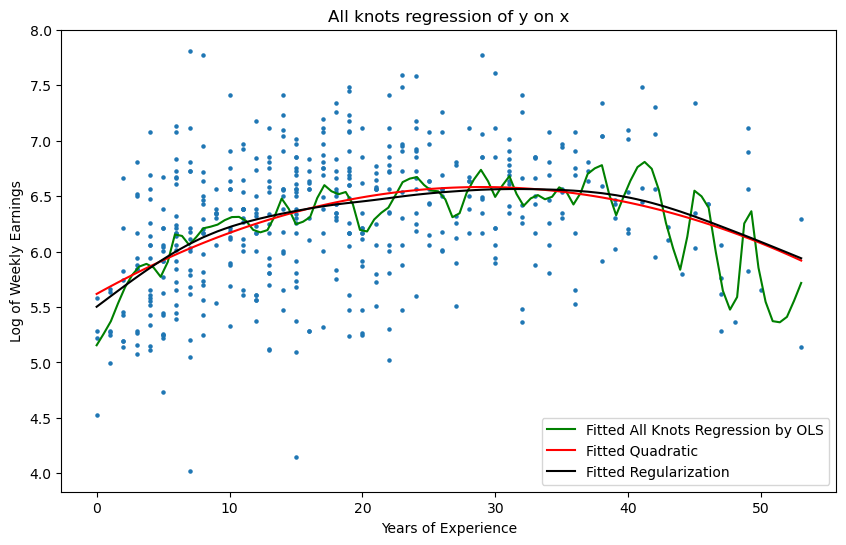

In [30]:
gamma_value = 0.0001
gamma_value = 0.0223
J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma_value**(-2), m-1)])) 
Mat =  X.T @ X + J_by_gammasq
Matinv = np.linalg.inv(Mat)
betahat_gamma = Matinv @ X.T @ y.to_numpy().reshape(-1, 1)

#calculating the fitted values for a grid of x-values:
x_range = np.linspace(x.min(), x.max(), 100)

X_range = pd.DataFrame({'const': 1, 'x': x_range})
kmax = m-1
for knot in range(1, (1 + kmax)):
    X_range[f'knot_{knot}'] = np.maximum(x_range - knot, 0)

fitted_model_postmean_gamma = X_range.values @ betahat_gamma

plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.plot(x_range,fitted_model_postmean_gamma, color = 'black', label = 'Fitted Regularization')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()



We next describe the posterior of $\gamma$ and $\sigma$. The posterior of $\sigma$ conditional on $\gamma$ can be described in closed form as: 

 \begin{equation*}
   \frac{1}{\sigma^2} \mid \text{data}, \gamma \sim \text{Gamma} \left(\frac{n}{2} - 1, \frac{y^T y - y^T X (X^T X + \gamma^{-2} J)^{-1} X^T y}{2} \right) 
 \end{equation*}
 Finally the posterior of $\gamma$ is given by: 

 \begin{align*}
   \gamma \mid \text{data} \sim \gamma^{-n+1} \sqrt{\det (X^T X + \gamma^{-2} J)^{-1}} \left(\frac{1}{y^T y - y^T X (X^T X + \gamma^{-2} J)^{-1} X^T y} \right)^{(n/2) - 1}
 \end{align*}

 We can compute this posterior on a grid of $\gamma$ values. Now we only need a 1D grid for $\gamma$. 

In [31]:
gamma_gr = np.logspace(np.log10(1e-6), np.log10(1e4), 2000)
logpost_gamma = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    sgn, logcovdet = np.linalg.slogdet(Matinv)
    logpost_gamma[i] =(-m)*np.log(gamma) + 0.5 * logcovdet - (n/2 - 1)*np.log(y.T @ y - y.T @ X @ Matinv @ X.T @ y)


Below we compute the posterior of $\gamma$ (correctly normalized) as well as the posterior mean. 

In [32]:
post_gamma  = np.exp(logpost_gamma - np.max(logpost_gamma))
post_gamma = post_gamma/np.sum(post_gamma)
postmean_gamma = np.sum(gamma_gr * post_gamma)
print(postmean_gamma)
print(1/(postmean_gamma ** 2)) #this is lambda = 1/gamma^2

0.02237592762348358
1997.2751693701425


Below we plot the posterior of $\gamma$ as a function of $\gamma$. The x-axis is on the log-scale. 

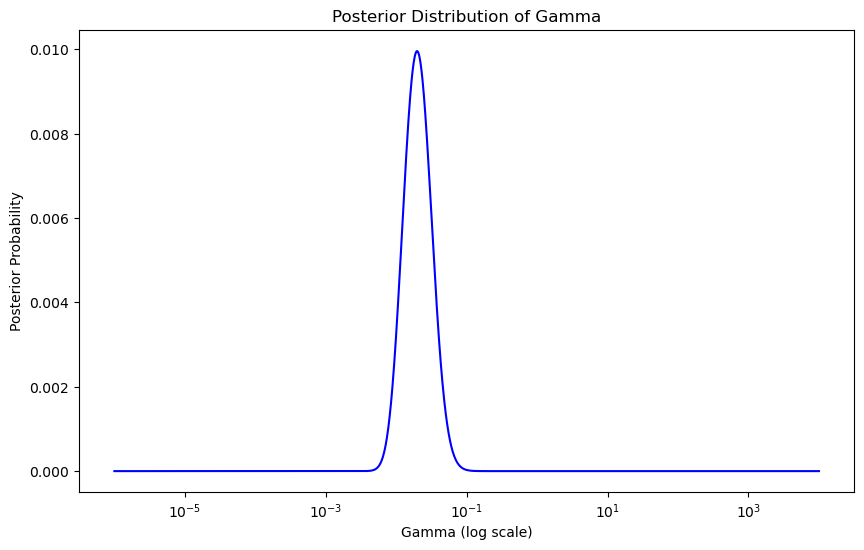

In [33]:
#Plotting post_gamma as a function of gamma:
plt.figure(figsize = (10, 6))
plt.plot(gamma_gr, post_gamma, color = 'blue')
plt.xscale('log')
plt.xlabel('Gamma (log scale)')
plt.ylabel('Posterior Probability')
plt.title('Posterior Distribution of Gamma')
plt.show()

Clearly, there is a single well-defined peak in this posterior distribution for $\gamma$. This means that the model is preferring a specific value of $\gamma$ that is neither too big nor too small. We can create samples from this posterior of $\gamma$ by simply sampling from the discretized distribution. 

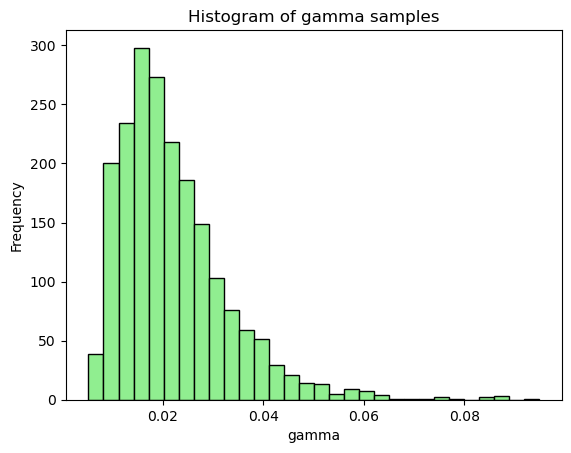

In [34]:
N = 2000
gamma_samples = np.random.choice(gamma_gr, size=N, p=post_gamma, replace=True)
plt.hist(gamma_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of gamma samples')
plt.xlabel('gamma')
plt.ylabel('Frequency')
plt.show()

Using the samples of $\gamma$, samples from $\beta$ and $\sigma$ can be constructed as follows. 

In [35]:
sig_samples = np.zeros(N)
betahats = np.zeros((m+1, N))
for i in range(N):
    gamma = gamma_samples[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    gamma_dist_lambda_parameter = (y.T @ y - y.T @ X @ Matinv @ X.T @ y)/2
    gamma_dist_alpha_parameter = n/2 - 1
    sig = np.sqrt(1/np.random.gamma(gamma_dist_alpha_parameter, 1/gamma_dist_lambda_parameter))
    sig_samples[i] = sig
    XTX = np.dot(X.T, X)
    TempMat = np.linalg.inv((J_by_gammasq/(sig ** 2)) + (XTX/(sig ** 2)))
    XTy = np.dot(X.T, y)
    #generate betahat from the normal distribution with mean: 
    norm_mean = np.dot(TempMat, XTy/(sig ** 2)) 
    #and covariance matrix: 
    norm_cov = TempMat  
    betahat = np.random.multivariate_normal(norm_mean, norm_cov)
    betahats[:,i] = betahat
    

The overall estimate of $\beta$ can be obtained by taking the mean of the individual $\beta$ samples. This is the posterior mean estimate of $\beta$ in the full Bayesian model. 

In [36]:
beta_est = np.mean(betahats, axis = 1)


Below we plot the fitted values corresponding to the posterior mean estimate of $\beta$. 

In [37]:
#calculating the fitted values for a grid of x-values:
x_range = np.linspace(x.min(), x.max(), 100)

X_range = pd.DataFrame({'const': 1, 'x': x_range})
for knot in range(1, (1 + kmax)):
    X_range[f'knot_{knot}'] = np.maximum(x_range - knot, 0)

fitted_model_postmean_fullmodel = X_range.values @ beta_est



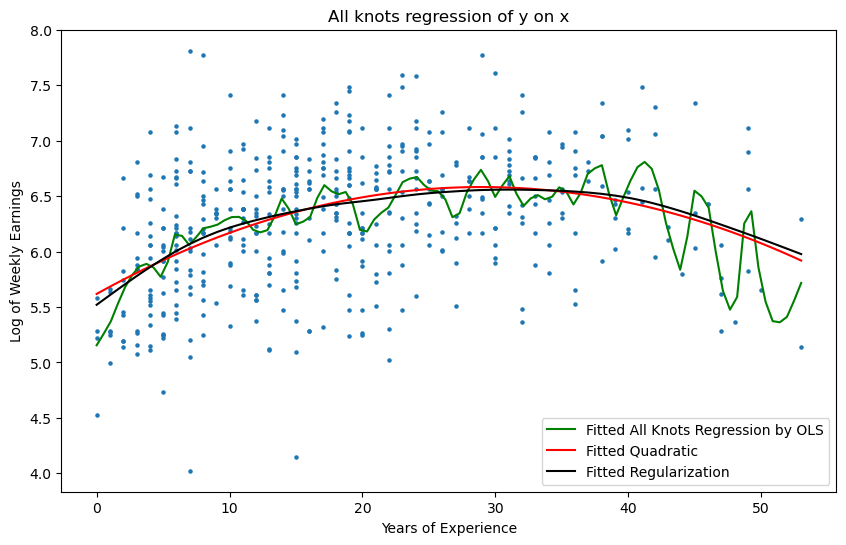

In [38]:
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(x_range,fitted_model_all_knots, color = 'green', label = 'Fitted All Knots Regression by OLS')
plt.plot(x_range,fitted_model_quad, color = 'red', label = 'Fitted Quadratic')
plt.plot(x_range,fitted_model_postmean_fullmodel, color = 'black', label = 'Fitted Regularization')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('All knots regression of y on x')
plt.legend()
plt.show()

It is interesting that the posterior mean estimate of $\beta$ corresponds to a smooth estimate of the underlying regression curve. 

Below we plot the individual curves coming from posterior samples of $\beta$. This gives an idea of the uncertainty associated with the fitted regression function. 

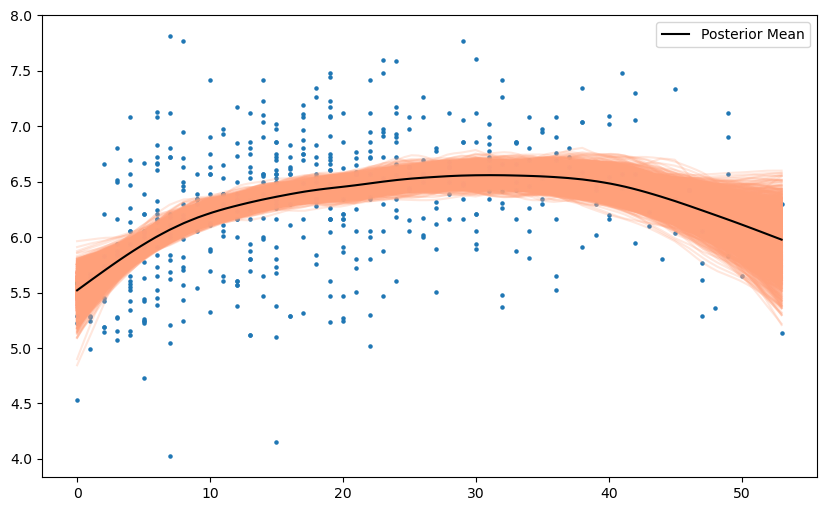

In [39]:
#Plotting all the posterior fitted values: 
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
for i in range(N):
    fitted_model_postdraw = X_range.values @ betahats[:,i]
    plt.plot(x_range, fitted_model_postdraw, color = 'lightsalmon', alpha = 0.25)
plt.plot(x_range, fitted_model_postmean_fullmodel, color = 'black', label = 'Posterior Mean')
plt.legend()
plt.show()


It is interesting that the uncertainty bands get wider near the end of the dataset where the data is sparse. Go back and repeat the analysis on the whole dataset (as opposed to the sample dataset of smaller size 500).

To summarize, this is again an example of Gaussian prior and a Gaussian likelihood with conjugacy being exploited. We took a high dimensional model; set the variance of the betas to be a hyper parameter as well as sigma. The full Bayesian solution as well as the Empirical Bayes solution both worked very well in this example too. The posterior mean of the betas is identical to ridge regression with $\lambda = \frac{1}{\gamma^2}. The full bayesian solution found a good lambda and sigma very organically and naturally. It automatically preferred a smooth fitted curve and gives uncertainty estimates everywhere by producing complete posterior distributions of all unknown parameters. The overall solution feels very satisfactory in this problem, with no further tuning needed. The only modelling step is the prior and the likelihood.  
